In [58]:
#imports
import pandas as pd
from plotnine import *
from sklearn.feature_selection import f_classif, SelectKBest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Exploratory Data Analysis

In [2]:
#read in and view training data
training = pd.read_csv("/Users/donyabehroozi/Downloads/playground-series-s6e4/train.csv")
training.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [35]:
#read in and view test data
test = pd.read_csv("/Users/donyabehroozi/Downloads/playground-series-s6e4/test.csv")
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


## Basic data exploration

In [ ]:
#check if there are missing values in training data
training.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

There are no missing values in the training dataset.

In [47]:
#check if there are missing values in test data
test.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

There are no missing values in the test dataset.

In [7]:
#check if there are duplicates
training.duplicated().sum()

np.int64(0)

In [48]:
test.duplicated().sum()

np.int64(0)

There are no duplicates of rows in either dataset.

In [6]:
#explore data types
training.dtypes

id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

There are 9 categorical variables (including our outcome variable) and 12 quantitative variables.

In [ ]:
#display summary statistics of quantitative variables in training data
training.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [49]:
#display summary statistics of quantitative variables in test data
test.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [ ]:
#display some summary statistics for categorical variables in training data
training.describe(include=['object'])

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region,Irrigation_Need
count,630000,630000,630000,630000,630000,630000,630000,630000,630000
unique,4,6,4,3,4,4,2,5,3
top,Sandy,Sugarcane,Harvest,Kharif,Canal,Reservoir,No,South,Low
freq,166509,108910,167689,216561,161901,162994,316453,134809,369917


In [50]:
#display some summary statistics for categorical variables in test data
test.describe(include=['object'])

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
count,270000,270000,270000,270000,270000,270000,270000,270000
unique,4,6,4,3,4,4,2,5
top,Sandy,Sugarcane,Harvest,Kharif,Canal,Reservoir,No,South
freq,71293,46110,71992,92893,69663,69928,136183,57795


The training and test data set variable summary statistics are very similar.

In [ ]:
#unique values for each category (courtesty of @wesleyhuan's notebook)
categorical_variables = training.select_dtypes(include=["object"]).columns.tolist()
for column in categorical_variables:
    print(column, ":", training[column].unique())

Soil_Type : ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type : ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage : ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season : ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type : ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source : ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used : ['No' 'Yes']
Region : ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need : ['Low' 'Medium' 'High']


## Visualization of outcome variable: Irrigation Need

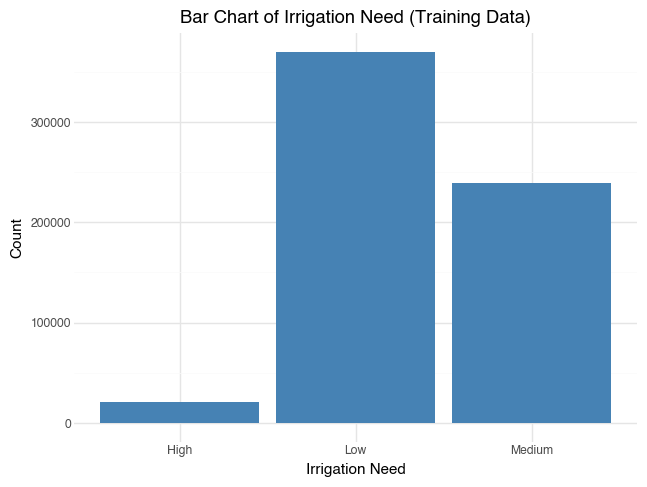

In [34]:
(
    ggplot(training, aes(x="Irrigation_Need"))
    + geom_bar(fill = "steelblue")
    + labs(title="Bar Chart of Irrigation Need (Training Data)", x="Irrigation Need", y="Count")
    + theme_minimal()
)

This dataset is very imbalanced. There are very few "high" classifications compared to "low" and "medium" classifications. "Low" classifications dominate this outcome variable.

## Feature importance: quantitative variables

Idea courtesty of @rawashishsin on Kaggle

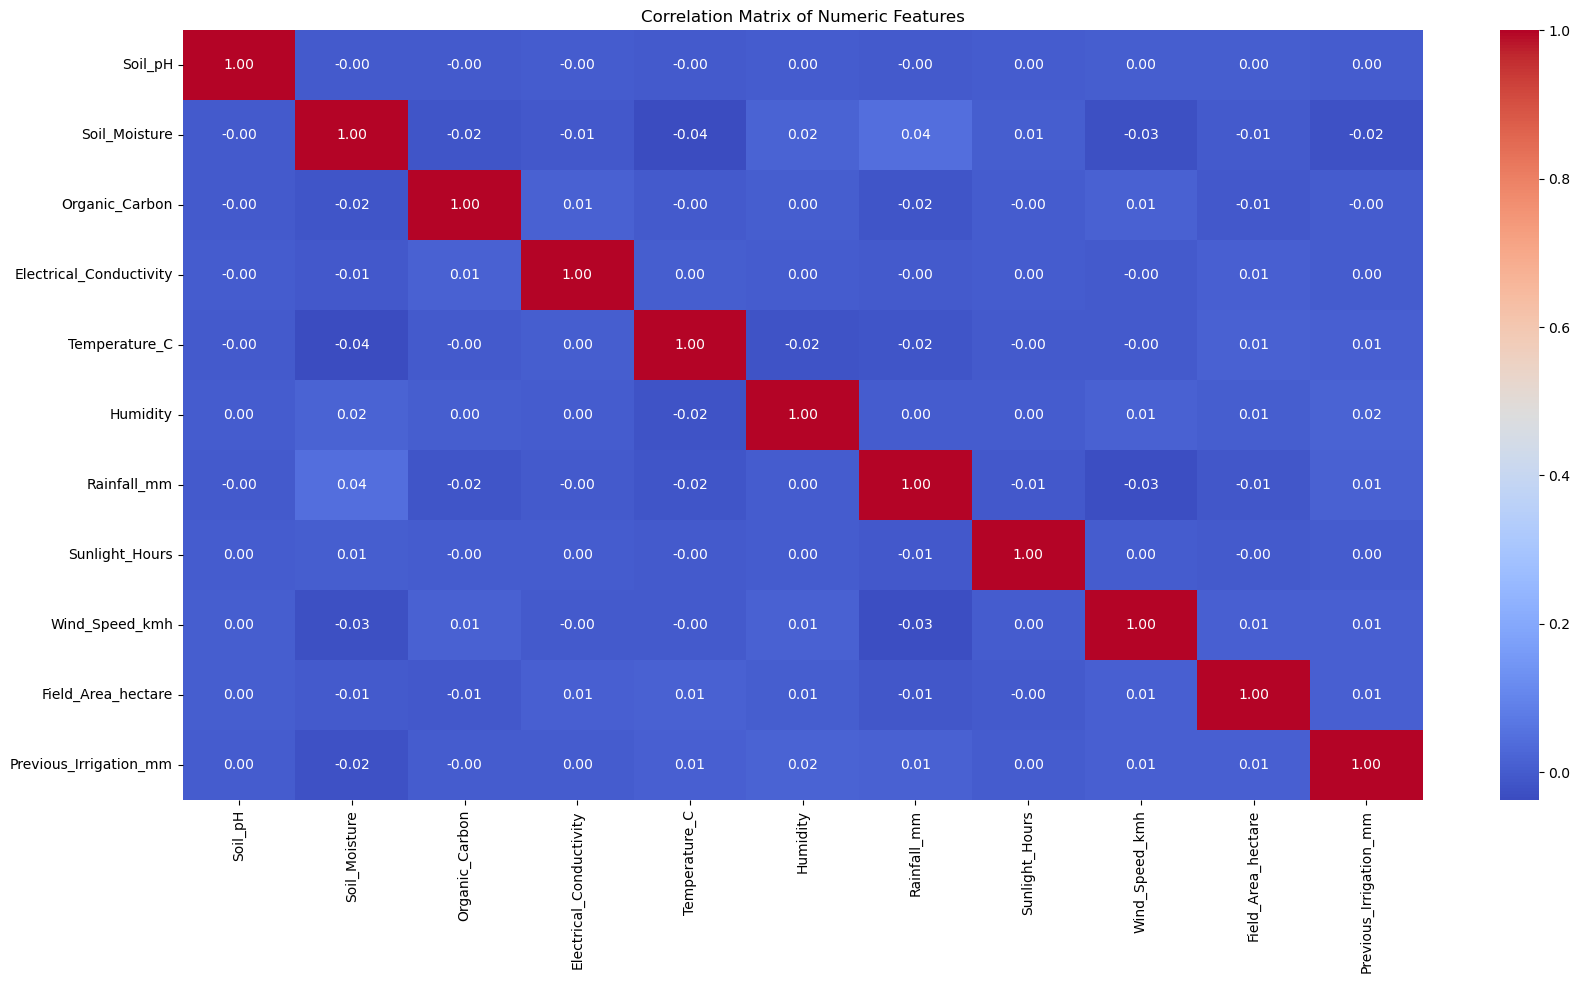

In [64]:
#first use correlation matrix to check whether there are any redundant/highly correlated numeric variables (idea courtesty of @wesleyhuan on Kaggle)

numeric_cols = training.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["id"]]

corr_matrix = training[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.show()

There is no high correlation between any of the numeric variables, so I will not be dropping any of these variables as there is no clear redundancy.

In [53]:
#run ANOVA F-test for all numeric features
X_num = training[numeric_cols].copy()
y = training["Irrigation_Need"].copy()

f_stats, p_vals = f_classif(X_num, y)

anova_df = pd.DataFrame({
    "feature": numeric_cols,
    "f_stat": f_stats,
    "p_value": p_vals
}).sort_values("f_stat", ascending=False).reset_index(drop=True)

print(anova_df.head(10))

                   feature        f_stat       p_value
0            Soil_Moisture  82555.917860  0.000000e+00
1           Wind_Speed_kmh  22514.094175  0.000000e+00
2            Temperature_C  22043.759085  0.000000e+00
3              Rainfall_mm   7241.631185  0.000000e+00
4                 Humidity    172.297278  1.558475e-75
5                  Soil_pH    158.296161  1.862596e-69
6  Electrical_Conductivity    146.958066  1.555271e-64
7   Previous_Irrigation_mm    137.644058  1.717915e-60
8       Field_Area_hectare    130.155193  3.061912e-57
9           Organic_Carbon     16.167903  9.518080e-08


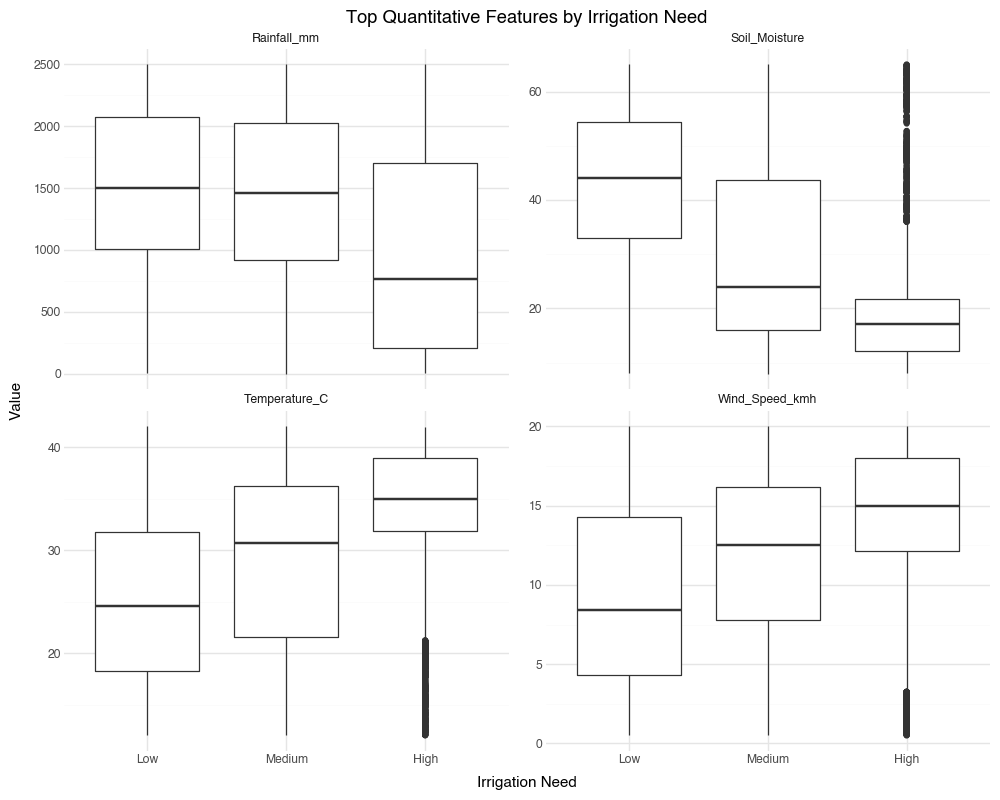

In [55]:
top_features = [
    "Soil_Moisture",
    "Wind_Speed_kmh",
    "Temperature_C",
    "Rainfall_mm"
]

plot_data = training[["Irrigation_Need"] + top_features].copy()

plot_data["Irrigation_Need"] = pd.Categorical(
    plot_data["Irrigation_Need"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

plot_data = plot_data.melt(
    id_vars="Irrigation_Need",
    value_vars=top_features,
    var_name="feature",
    value_name="value"
)

(
    ggplot(plot_data, aes(x="Irrigation_Need", y="value"))
    + geom_boxplot()
    + facet_wrap("~feature", scales="free_y", ncol=2)
    + labs(
        title="Top Quantitative Features by Irrigation Need",
        x="Irrigation Need",
        y="Value"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        axis_text_x=element_text(rotation=0)
    )
)


## Feature importance: categorical variables

Courtesty of @rawashishsin

In [39]:
#select categorical variables only
categorical_cols = training.select_dtypes(exclude=["number"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != "Irrigation_Need"]
categorical_cols

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

In [40]:
#run chi^2 for all categorical features
X_cat = training[categorical_cols].copy()
y = training["Irrigation_Need"].copy()

chi2_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(X_cat[col], y)
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({
        "feature": col,
        "chi2_stat": chi2_stat,
        "p_value": p_val
    })

chi2_df = pd.DataFrame(chi2_results) \
    .sort_values("chi2_stat", ascending=False) \
    .reset_index(drop=True)

print(chi2_df.head(10))

             feature      chi2_stat        p_value
0  Crop_Growth_Stage  194378.520268   0.000000e+00
1      Mulching_Used   56876.904242   0.000000e+00
2       Water_Source    1642.705118   0.000000e+00
3    Irrigation_Type    1096.452744  1.221198e-233
4          Crop_Type    1094.944060  6.491332e-229
5          Soil_Type     406.316493   1.225770e-84
6             Season     373.469659   1.498438e-79
7             Region     188.513828   1.672727e-36


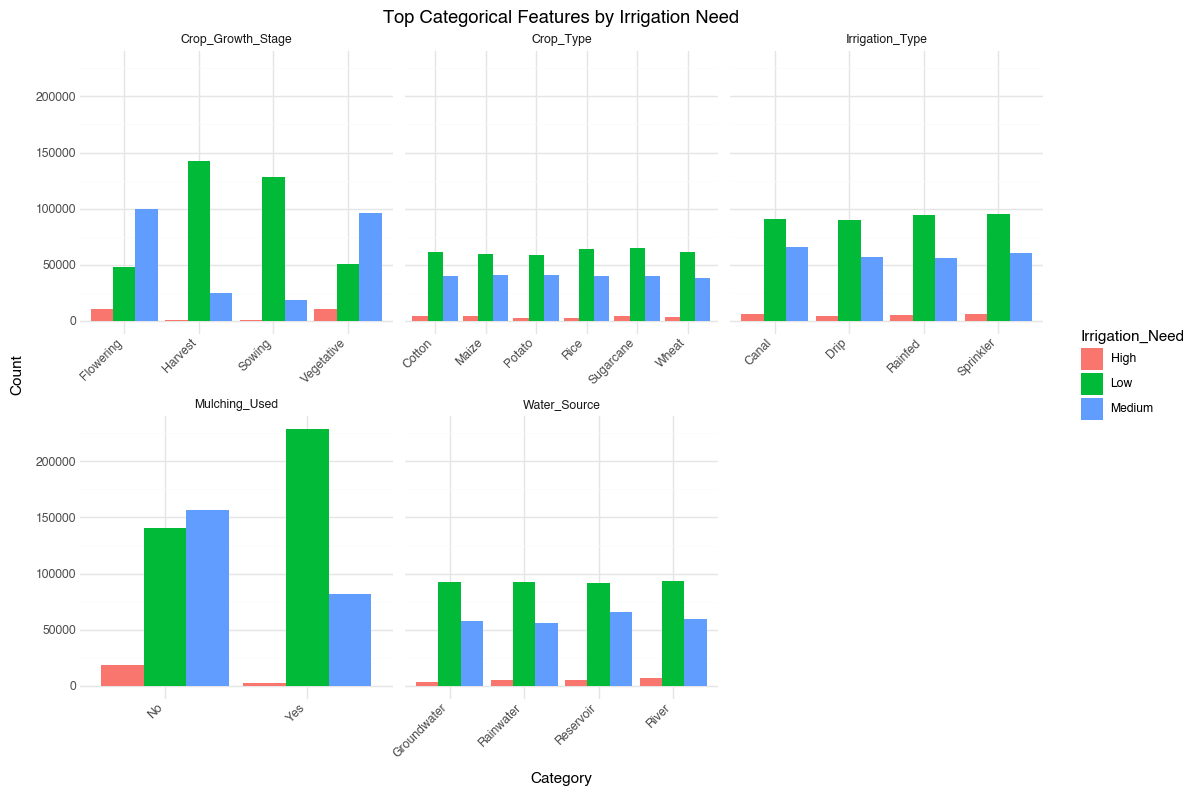

In [65]:
top_cat_features = [
    "Crop_Growth_Stage",
    "Mulching_Used",
    "Water_Source",
    "Irrigation_Type",
    "Crop_Type"
]

plot_data = training[top_cat_features + ["Irrigation_Need"]].copy()

plot_data = plot_data.melt(
    id_vars="Irrigation_Need",
    value_vars=top_cat_features,
    var_name="feature",
    value_name="category"
)

(
    ggplot(plot_data, aes(x="category", fill="Irrigation_Need"))
    + geom_bar(position="dodge")
    + facet_wrap("~feature", scales="free_x")
    + labs(
        title="Top Categorical Features by Irrigation Need",
        x="Category",
        y="Count"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text_x=element_text(rotation=45, ha="right")
    )
)

The most important numerical variable appears to be soil moisture due to having the largest F-statistic. The most important categorical variable appears to be crop growth stage due to having the largest chi-square statistic. The visuals show clear separation between low, medium, and high irrigation need for these variables.